## Paper

In [1]:
from matplotlib import pyplot as plt
import numpy as np

from predhpc import paper
from predhpc.util import plot_util

%load_ext autoreload

In [2]:
%autoreload 2

In [3]:
paper.initialize_paper_parameters(gen_dir="..", notebook=True)
ALL_FIGURES = dict()

### Fig. 1: Background

Figure saved to /home/cgillon/homedir/predhpc/results/paper/1B.png  & .svg


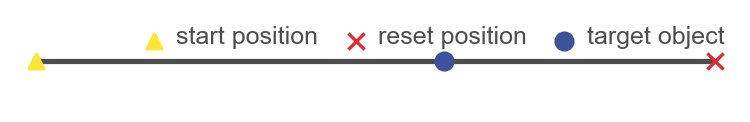

In [4]:
fig, panel = 1, "B"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(fig=fig, panel=panel)

Figure saved to /home/cgillon/homedir/predhpc/results/paper/1D.png  & .svg


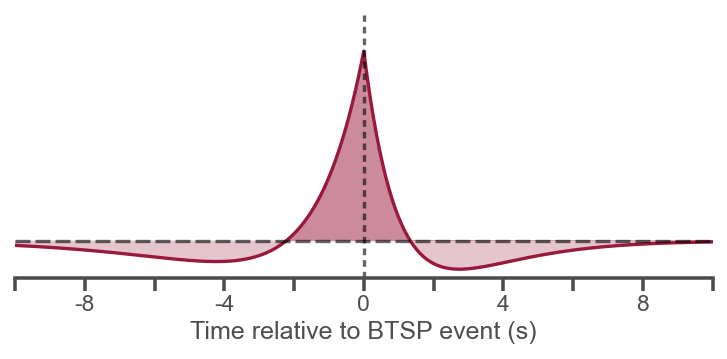

In [5]:
fig, panel = 1, "D"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(fig=fig, panel=panel)

### Fig. 2: Linear track
BTSP event recorded at step 513 and applied at step 1207.

In [6]:
linear_learner = paper.run_linear(max_time_min=1.8)

 17%|██████▌                                | 605/3600 [00:00<00:04, 746.01it/s]

BTSP event recorded at step 513 (15.39 sec).


 38%|██████████████▎                       | 1352/3600 [00:01<00:03, 721.26it/s]

BTSP update applied at step 1207 (36.21 sec).


100%|██████████████████████████████████████| 3600/3600 [00:05<00:00, 697.09it/s]


Finishing last trajectory.


1131it [00:01, 677.12it/s]

Only reached target 4 times (target: 10).
Trajectory lengths (5) to date: 28.39 +/- 15.36 sec each
Trajectory lengths (5) to date: 946.40 +/- 511.95 steps each
1 BTSP event triggered (allowed from steps 0 to 4731): occurred at step 513.


Figure saved to /home/cgillon/homedir/predhpc/results/paper/2A.png  & .svg


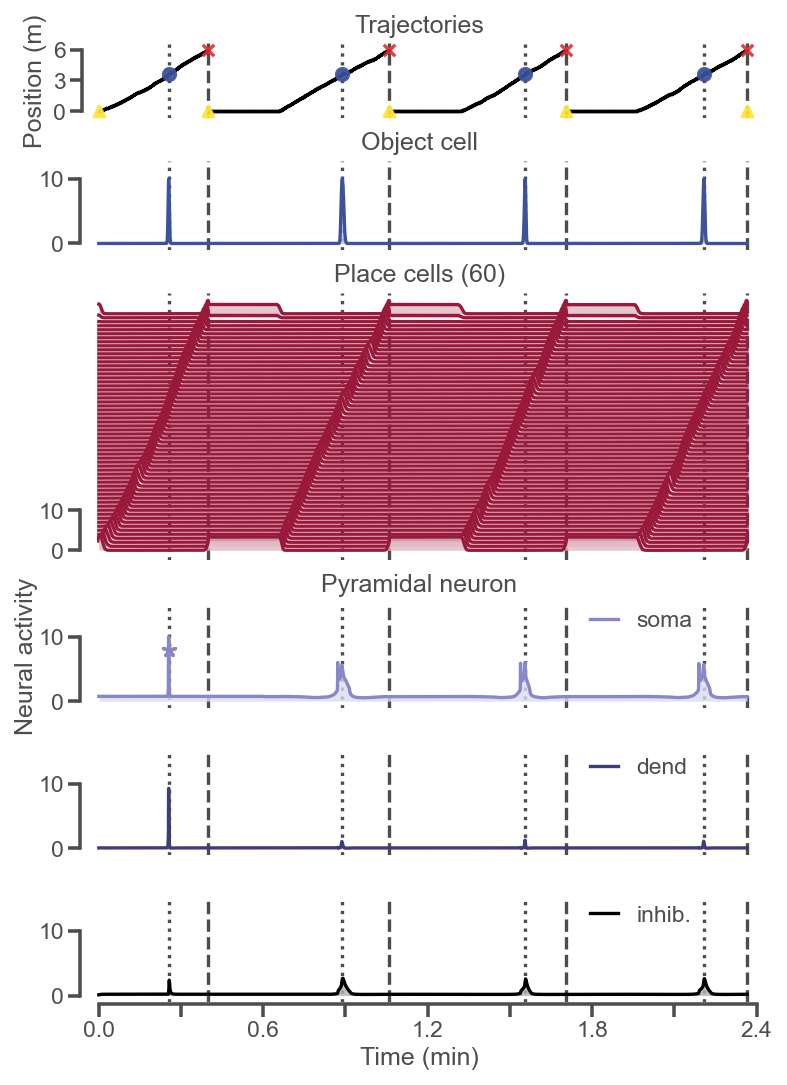

In [7]:
fig, panel = 2, "A"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(linear_learner, fig=fig, panel=panel)

In [99]:
from predhpc.experiments import metrics
from predhpc.util import signal_util

weights, centres, peak_idx = metrics.get_PC_info(linear_learner.Pyrs)
sm_weights, centres, peak_idx = metrics.get_PC_info(linear_learner.Pyrs, smoothed=True)
eff_weights, centres, peak_idx = metrics.get_PC_info(linear_learner.Pyrs, effective=True, max_recurrence=14)

weights_adj = signal_util.rescale_data(weights, target_range=[0, 1], pad_prop=0)
weights_adj = weights_adj * (eff_weights.max() - eff_weights.min()) + eff_weights.min()

sm_weights_adj = signal_util.rescale_data(sm_weights, target_range=[0, 1], pad_prop=0)
sm_weights_adj = sm_weights_adj * (eff_weights.max() - eff_weights.min()) + eff_weights.min()

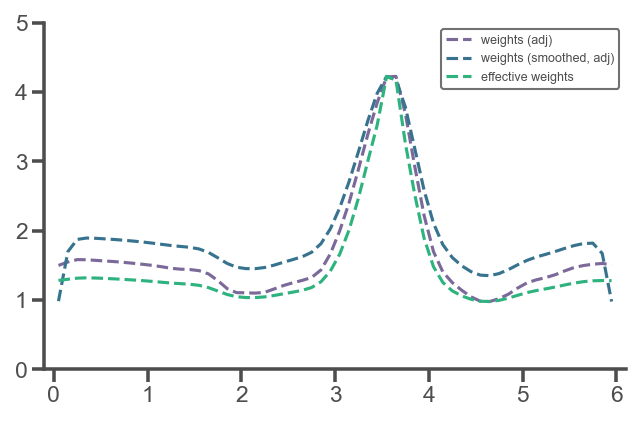

In [106]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(centres, weights_adj, label="weights (adj)", lw=1.5, ls="dashed")
ax.plot(centres, sm_weights_adj, label="weights (smoothed, adj)", lw=1.5, ls="dashed")
ax.plot(centres, eff_weights, label="effective weights", lw=1.5, ls="dashed")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(-0.1, 6.1)
ax.set_ylim(0, 5)
ax.legend();

Figure saved to /home/cgillon/homedir/predhpc/results/paper/2B.png  & .svg


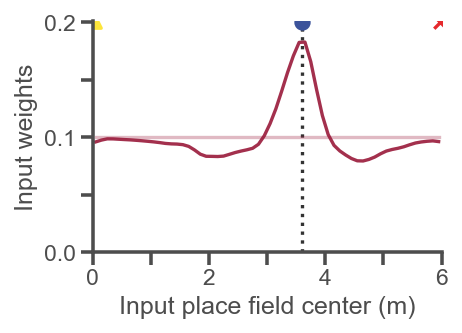

In [8]:
fig, panel = 2, "B"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(linear_learner, fig=fig, panel=panel)

Figure saved to /home/cgillon/homedir/predhpc/results/paper/2C.png  & .svg


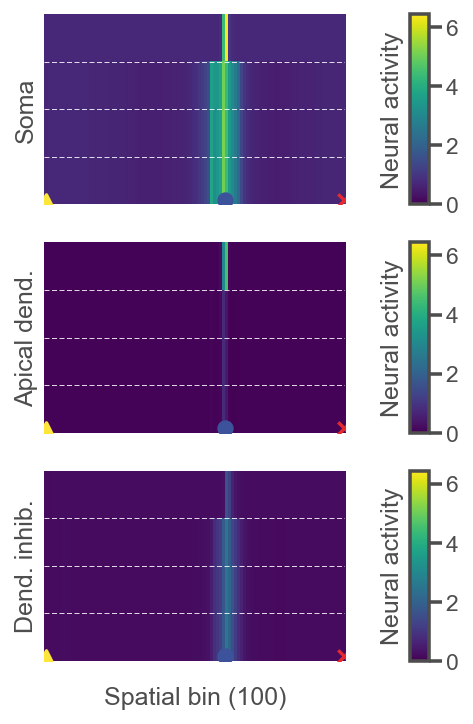

In [9]:
fig, panel = 2, "C"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(linear_learner, fig=fig, panel=panel)

## TO FIX!!!
The place field figures show **input weights**, not place fields as would be measured in a pyramidal neuron.

### Fig. 3: Speed and PF width
Takes about 2.5 min to rerun.  

In [10]:
speed_data = paper.run_linear_fct("linear_speeds", overwrite=False)

Loading data from ../results/paper/speed_data_18.npz.


Figure saved to /home/cgillon/homedir/predhpc/results/paper/3A.png  & .svg


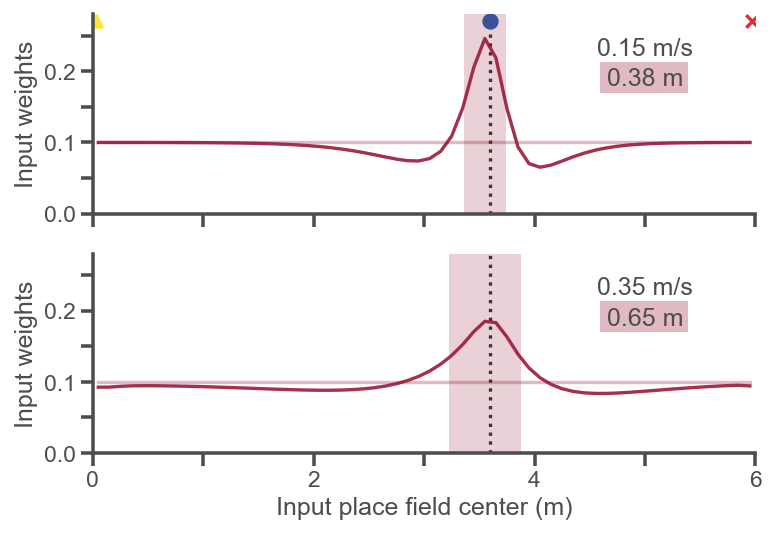

In [11]:
fig, panel = 3, "A"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(speed_data, fig=fig, panel=panel)

Figure saved to /home/cgillon/homedir/predhpc/results/paper/3B.png  & .svg


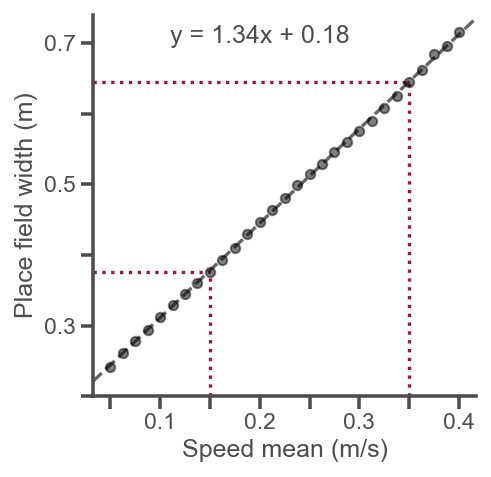

In [12]:
fig, panel = 3, "B"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(speed_data, fig=fig, panel=panel)

### Fig. 4: Effect of linear shifts
Takes about 5 min to rerun.

In [13]:
shift_data = paper.run_linear_fct("linear_shifts", overwrite=False)

Loading data from ../results/paper/shift_data_18.npz.


Figure saved to /home/cgillon/homedir/predhpc/results/paper/4A.png  & .svg


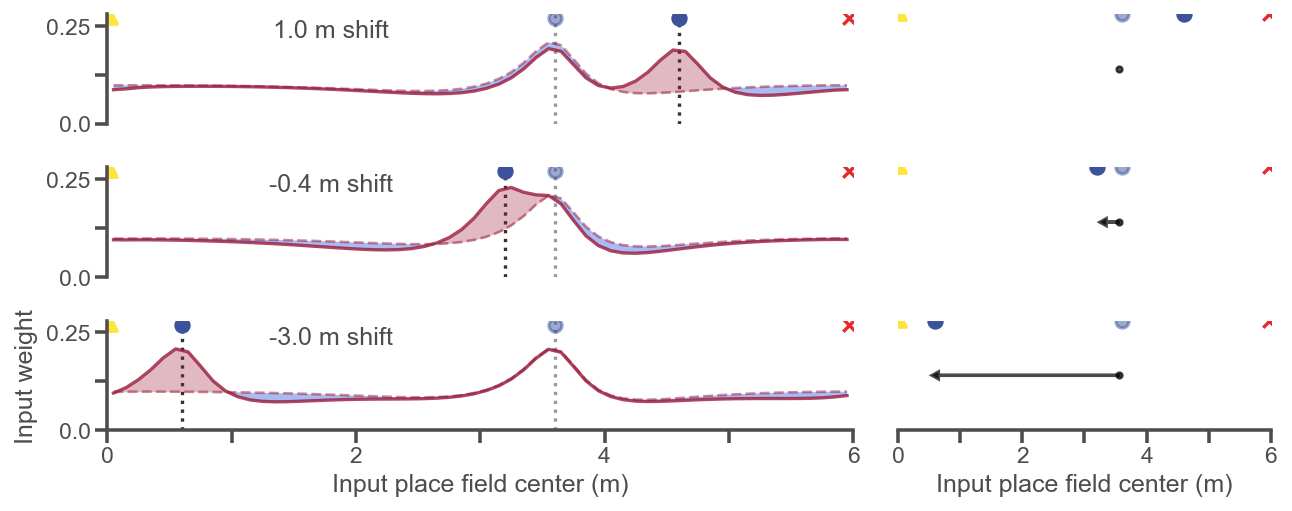

In [14]:
fig, panel = 4, "A"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(shift_data, fig=fig, panel=panel)

Figure saved to /home/cgillon/homedir/predhpc/results/paper/4B.png  & .svg


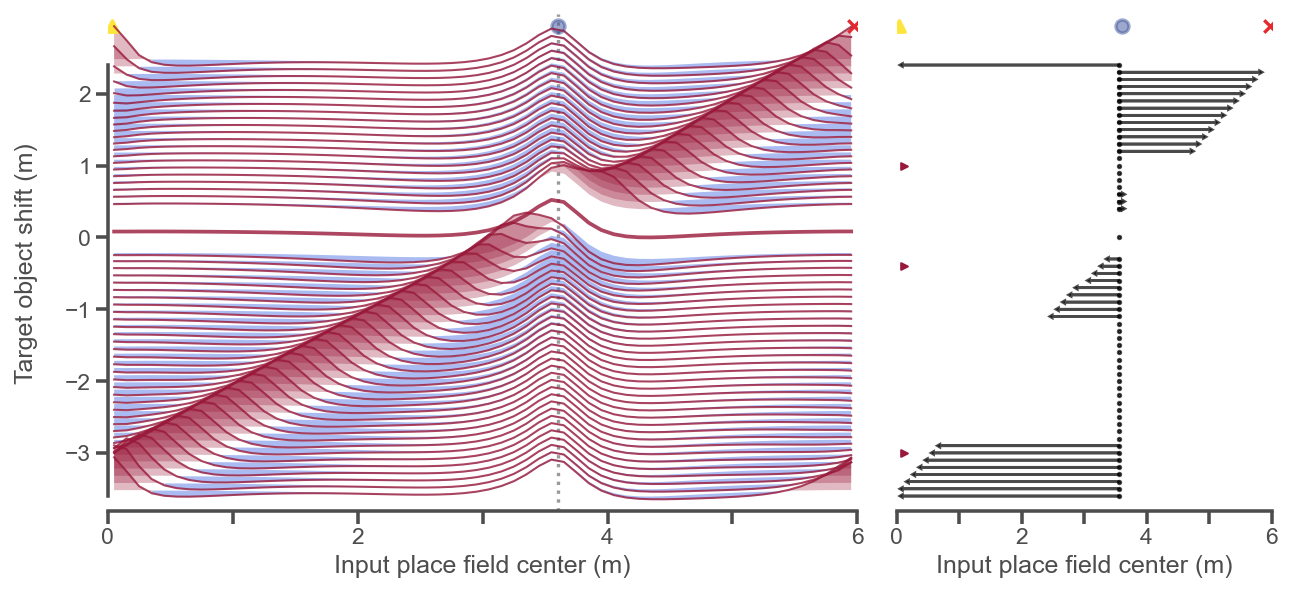

In [15]:
fig, panel = 4, "B"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(shift_data, fig=fig, panel=panel)

### Fig. 5: 2D environment and teleportation
BTSP event recorded at step 1095 and applied at step 1789.

In [16]:
learner = paper.run_openfield_corridor()

  8%|██▊                                  | 1148/15000 [00:03<00:46, 297.21it/s]

BTSP event recorded at step 1095 (32.85 sec).


 12%|████▌                                | 1838/15000 [00:06<00:42, 308.14it/s]

BTSP update applied at step 1789 (53.67 sec).


100%|████████████████████████████████████| 15000/15000 [00:44<00:00, 334.17it/s]

Reached target 27 times.
Trajectory lengths (8) to date: 56.25 +/- 9.92 sec each
Trajectory lengths (8) to date: 1875.00 +/- 330.72 steps each
1 BTSP event triggered (allowed from steps 0 to 14999): occurred at step 1095.


Figure saved to /home/cgillon/homedir/predhpc/results/paper/5A-D.png  & .svg


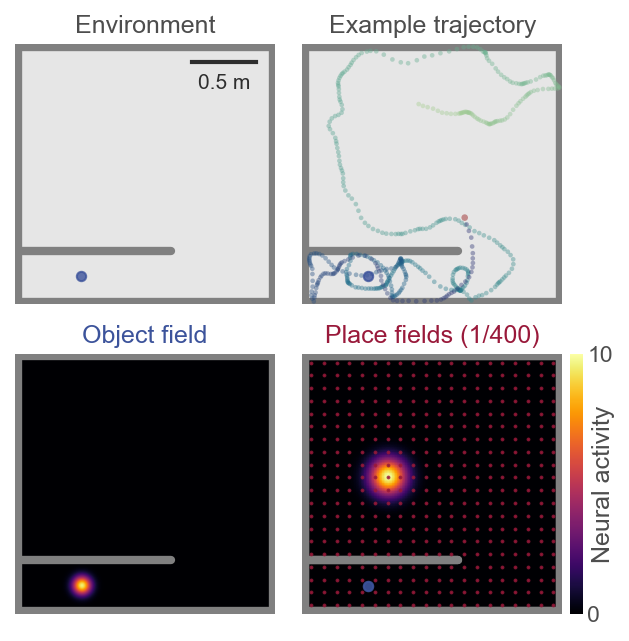

In [17]:
fig, panel = 5, "A-D"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(learner.Pyrs, fig=fig, panel=panel)

Figure saved to /home/cgillon/homedir/predhpc/results/paper/5E.png  & .svg


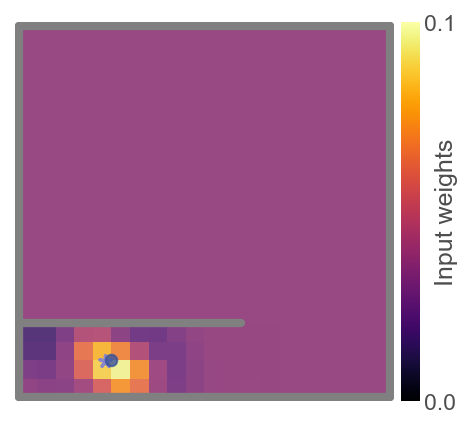

In [41]:
fig, panel = 5, "E"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(learner.Pyrs, fig=fig, panel=panel)

Figure saved to /home/cgillon/homedir/predhpc/results/paper/5F.png  & .svg


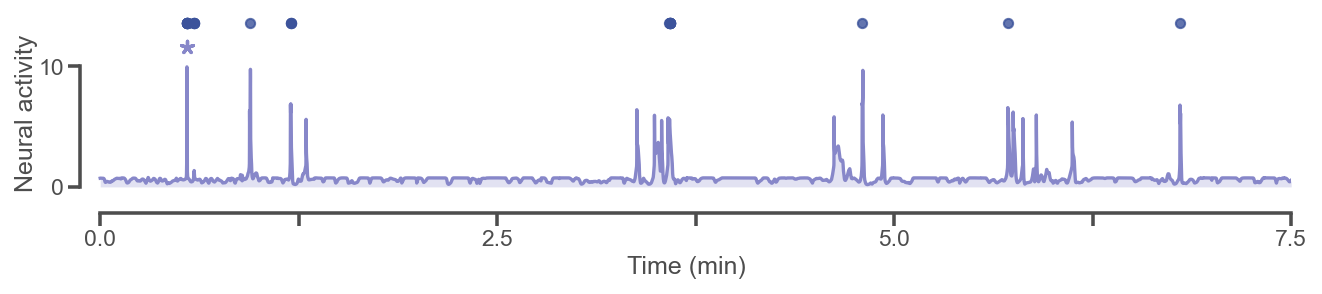

In [40]:
fig, panel = 5, "F"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(learner.Pyrs, fig=fig, panel=panel)

### Fig. 6: Teleportation

A: Teleportation ports  
B: Teleportation trajectory  
C: Remapped place field

### Fig. 7: Multiple targets

A: environment with multiple objects  
B: object fields  
C: trajectory examples  
D: 5 examples PFs  
E: all place fields overlaid  
F: BTSP events  
G: relationship between visits and number of BTSP events  

### Fig. 8: Remapping

A: remapping  
B: remapped  
C: correlation pre post

### Save figures

In [ ]:
SAVE = True

In [ ]:
if SAVE:
    print(f"Saving {len(ALL_FIGURES)} figures...")
    for key, ax in ALL_FIGURES.items():
        fig = ax.ravel()[0].figure if isinstance(ax, np.ndarray) else ax.figure
        plot_util.save_figure(fig, key, no_timestamp=True)